In [2]:

#EVENT RATE FUNCTIONS CELL
import target_io
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import os
import matplotlib.colors as colors
import matplotlib.patches as patches
from numba import njit


#get the reader object with your r0_file_path, chosen pedestal path, and r1_file_path if one exists

def get_reader(r0_path, tcal_path, r1_path):

    tcal_ped_path = tcal_path

    r0_file_path = r0_path

    file_path = r1_path
    
    os.system(f"apply_calibration_SCT -p {tcal_ped_path} -i {r0_file_path} -o {file_path}") # This will calibrate the data and make a r1 file
        
    reader = target_io.WaveformArrayReader(file_path)
    return reader

#start of stat collection sequence

def read_wfs(calfile, save=False, reader = None):
    if reader == None:
        reader = target_io.WaveformArrayReader(calfile, silent=True)
    all_wfs=[]
    times = []
    for ev in range(reader.fNEvents):
        wfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
        reader.GetR1Event(ev, wfs)
        times.append(float(reader.fTACK_time))
        all_wfs.append(wfs)
    all_wfs = np.array(all_wfs)
    if save:
        np.save(calfile.replace(".tio",".npy"), all_wfs)
    for wf in all_wfs:
        wf[4*64 + 14, :] = np.nan
        # for l in range(64):
        wf[5*64:6*64, :] = np.nan
        wf[13*64:14*64, :] = np.nan
        wf[21*64:, :] = np.nan
    return all_wfs, times

@njit
def get_max_time(all_wfs):
    t_maxs = np.zeros(all_wfs.shape[:-1]) # shape (n_events, n_channels)
    t_maxs[:, :] = np.argmax(all_wfs[:, :], axis=-1) # find the index of the maximum value along the time axis for each event and channel
    return t_maxs

@njit
def get_int_charges(all_wfs, int_win=2, charge_ceiling = None):
    n_events, n_channels, n_samples = all_wfs.shape
    int_charge = np.zeros((n_events, n_channels))
    for ev in range(n_events):
        for ch in range(n_channels):
            t_max = np.argmax(all_wfs[ev, ch])
            if t_max > n_samples - int_win - 1:
                t_max = n_samples - int_win - 1
            elif t_max < int_win:
                t_max = int_win
            int_charge[ev, ch] = all_wfs[ev, ch, t_max-int_win:t_max+int_win+1].sum()
        if charge_ceiling != None:
            for ch in range(n_channels):
                if int_charge[ev, ch] < charge_ceiling:
                    int_charge[ev, ch] = np.nan
    return int_charge


@njit
def get_event_stats(int_charges, peak_times):
    A = 30
    B = 15
    n_events, n_channels = int_charges.shape
    chg_means = np.zeros(n_events)
    chg_sums = np.zeros(n_events)
    chg_stds = np.zeros(n_events)
    time_means = np.zeros(n_events)
    time_stds = np.zeros(n_events)
    for n, chg_ev,  time_ev in zip(range(n_events), int_charges, peak_times):
        chg_means[n] = np.nanmean(chg_ev)
        chg_sums[n] = np.nansum(chg_ev)
        chg_stds[n] = np.nanstd(chg_ev)
        time_means[n] = np.nanmean(time_ev)
        time_stds[n] = np.nanstd(time_ev)

    return time_means, time_stds, chg_means, chg_stds

def collect_stats(reader):

    all_wfs, timess = read_wfs(None, reader=reader)
    int_charges = get_int_charges(all_wfs, int_win=4)
    peak_times = get_max_time(all_wfs)
    stats_all = get_event_stats(int_charges, peak_times)


    return all_wfs, stats_all[0], stats_all[1], stats_all[2], stats_all[3], timess

#returns the sr_data object which is sr[0]: all wfs, sr[1]: mean time, sr[1][ev]: mean time for an event, sr[2]: time std
#sr[3]: charge mean, sr[4]: charge std, sr[5]: event time

def get_cuts():
    chshowx_max=1250
    chshowx_min=25
    chshowy_max=2000
    chshowy_min=40

    chflashx_max=3750
    chflashx_min=2000
    chflashy_max=1750
    chflashy_min=800

    tshowx_max=1250
    tshowx_min=0
    tshowy_max=21.5
    tshowy_min=14

    tflashx_max=3750
    tflashx_min=2000
    tflashy_max=18
    tflashy_min=12
    return chshowx_max, chshowx_min, chshowy_max, chshowy_min, chflashx_max, chflashx_min, chflashy_max, chflashy_min, tshowx_max, tshowx_min, tshowy_max, tshowy_min, tflashx_max, tflashx_min, tflashy_max, tflashy_min

#establishes ranges for sorting boxes, make sure to have cuts=get_cuts
#
def get_hists(sr_data, cuts, display=True, regions=True, flashers=True, boxes=True):

    if display==True:

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

        plt.title("Charge std vs Mean Charge for all events")
        plt.xlabel("Mean charge (ADC*ns)")
        plt.ylabel("Charge std (ADC*ns)")
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[9],cuts[11]), width=(cuts[8]-cuts[9]), height=(cuts[10]-cuts[11]), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[13],cuts[15]), width=(cuts[12]-cuts[13]), height=(cuts[14]-cuts[15]), linewidth=1, color='red', fill=False))

        plt.title("Time std vs Mean Charge for all events")
        plt.xlabel("Mean charge (ADC*ns)")
        plt.ylabel("Time std (ns)")
        plt.show()


        if regions==True:

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range = [[cuts[1]-50,cuts[0]+50],[cuts[3]-50,cuts[2]+50]])
            
            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))

            plt.title("Charge std vs Mean Charge for all events (Noise/Shower region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Charge std (ADC*ns)")
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[9]-50,cuts[8]+50],[cuts[11]-3,cuts[10]+3]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[9],cuts[11]), width=(cuts[8]-cuts[9]), height=(cuts[10]-cuts[11]), linewidth=1, color='green', fill=False))

            plt.title("Time std vs Mean Charge for all events(Noise/Shower region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Time std (ns)")
            plt.show()

        if flashers==True:

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[4], bins = 500,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[5]-50,cuts[4]+50],[cuts[7]-50,cuts[6]+50]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

            plt.title("Charge std vs Mean Charge for all events (Flasher region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Charge std (ADC*ns)")
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[2], bins = 500,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[13]-50,cuts[12]+50],[cuts[15]-3,cuts[14]+3]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[13],cuts[15]), width=(cuts[12]-cuts[13]), height=(cuts[14]-cuts[15]), linewidth=1, color='red', fill=False))
                
            plt.title("Time std vs Mean Charge for all events(Flasher region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Time std (ns)")
            plt.show()

#makes histograms that help determine boxes for the sorting step, can control how many are created.

def sort_data(sr_data, cuts, list=False):
    ch_showers=[]
    t_showers=[]
    ch_flashers=[]
    t_flashers=[]
    ch_noise=[]
    t_noise=[]
    con_showers=[]
    con_flashers=[]
    con_noise=[]

    for ev in range(len(sr_data[0])):
        if sr_data[3][ev]>cuts[1] and sr_data[3][ev]<cuts[0] and sr_data[4][ev]>cuts[3] and sr_data[4][ev]<cuts[2]:
          ch_showers.append(ev)
        elif sr_data[3][ev]>cuts[5] and sr_data[3][ev]<cuts[4] and sr_data[4][ev]>cuts[7] and sr_data[4][ev]<cuts[6]:
            ch_flashers.append(ev)
        else:
            ch_noise.append(ev)

        if sr_data[3][ev]>cuts[9] and sr_data[3][ev]<cuts[8] and sr_data[2][ev]>cuts[11] and sr_data[2][ev]<cuts[10]:
            t_showers.append(ev)
        elif sr_data[3][ev]>cuts[13] and sr_data[3][ev]<cuts[12] and sr_data[2][ev]>cuts[15] and sr_data[2][ev]<cuts[14]:
            t_flashers.append(ev)
        else: 
            t_noise.append(ev)
    for eve in ch_showers:
        if eve in t_showers:
            con_showers.append(eve)
    for eve in ch_flashers:
        if eve in t_flashers:
            con_flashers.append(eve)
    for eve in ch_noise:
        if eve in t_noise:
            con_noise.append(eve)

    
    charge_showers=np.zeros((2,len(ch_showers)))
    for ind, ev in enumerate(ch_showers):
        charge_showers[0][ind]=ev
        charge_showers[1][ind]=sr_data[5][ev]
    
    charge_flashers=np.zeros((2,len(ch_flashers)))
    for ind, ev in enumerate(ch_flashers):
        charge_flashers[0][ind]=ev
        charge_flashers[1][ind]=sr_data[5][ev]

    charge_noise=np.zeros((2,len(ch_noise)))
    for ind, ev in enumerate(ch_noise):
        charge_noise[0][ind]=ev
        charge_noise[1][ind]=sr_data[5][ev]

    time_showers=np.zeros((2,len(t_showers)))
    for ind, ev in enumerate(t_showers):
        time_showers[0][ind]=ev
        time_showers[1][ind]=sr_data[5][ev]

    time_flashers=np.zeros((2,len(t_flashers)))
    for ind, ev in enumerate(t_flashers):
        time_flashers[0][ind]=ev
        time_flashers[1][ind]=sr_data[5][ev]

    time_noise=np.zeros((2,len(t_noise)))
    for ind, ev in enumerate(t_noise):
        time_noise[0][ind]=ev
        time_noise[1][ind]=sr_data[5][ev]

    conf_showers=np.zeros((2,len(con_showers)))
    for ind, ev in enumerate(con_showers):
        conf_showers[0][ind]=ev
        conf_showers[1][ind]=sr_data[5][ev]

    conf_flashers=np.zeros((2,len(con_flashers)))
    for ind, ev in enumerate(con_flashers):
        conf_flashers[0][ind]=ev
        conf_flashers[1][ind]=sr_data[5][ev]

    conf_noise=np.zeros((2,len(con_noise)))
    for ind, ev in enumerate(con_noise):
        conf_noise[0][ind]=ev
        conf_noise[1][ind]=sr_data[5][ev]
        
    if list==True:
       print('Showers:',len(con_showers),'\nFlahsers:', len(con_flashers), '\nNoise:', len(con_noise), '\nCharge Showers:',len(ch_showers),'\nCharge Flashers:', len(ch_flashers),'\nCharge Noise:',len(ch_noise),"\nTime Showers:",len(t_showers),'\nTime Noise',len(t_noise))
       
    return conf_showers, conf_flashers, conf_noise, charge_showers, charge_flashers, charge_noise, time_showers, time_flashers, time_noise
    
#sorts the data into 9 lists, should be used to create the sorted_data object which has 9 sections with 2 indexes each

#put function for displaying random sets of events here

def event_rate(sorted_data, sr_data, run_id, sr_number, mod=1, test=False):
    modifier=mod
    fig, ax = plt.subplots()
    ax.hist(sr_data[5], weights = [modifier for _ in range(len(sr_data[5]))], bins = np.arange(sr_data[5][0], sr_data[5][-1], 1E9/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_data[0][1], weights = [modifier for _ in range(len(sorted_data[0][1]))], bins = np.arange(sorted_data[0][1][0], sorted_data[0][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_data[1][1], weights = [modifier for _ in range(len(sorted_data[1][1]))], bins = np.arange(sorted_data[1][1][0], sorted_data[1][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_data[2][1], weights = [modifier for _ in range(len(sorted_data[2][1]))], bins = np.arange(sorted_data[2][1][0], sorted_data[2][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'NSB') 
    
    if test==True:
       ax.hist(sorted_data[3][1], weights = [modifier for _ in range(len(sorted_data[3][1]))], bins = np.arange(sorted_data[3][1][0], sorted_data[3][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'charge showers') 
       ax.hist(sorted_data[6][1], weights = [modifier for _ in range(len(sorted_data[6][1]))], bins = np.arange(sorted_data[6][1][0], sorted_data[6][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'time showers') 
   
    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {run_id}, sr{sr_number}")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Rate [Hz]")
    plt.show()

#makes histogram of rates with or without some test lines that help with refining box cuts  

def oldsr_evsummary(r0_file, tcal_file, r1_file, test=False, resolution=1):

    reader=get_reader(r0_file, tcal_file, r1_file)

    sr_data= collect_stats(reader)

    cuts=get_cuts()
    
    get_hists(sr_data, cuts, display=test, regions= test, flashers= test, boxes= test)

    sorted_data=sort_data(sr_data, cuts)

    event_rate(sorted_data, sr_data, test=test, mod=resolution)



In [ ]:
#EVENT RATES FUNCTION TEST (broken)

oldsr_evsummary('/data/user/fbivens5020/mock_data/run400196_subrun0_r4.tio', '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal',test=False, resolution=1)

TypeError: oldsr_evsummary() missing 1 required positional argument: 'r1_file'

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun5_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun5.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun5_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 2792
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

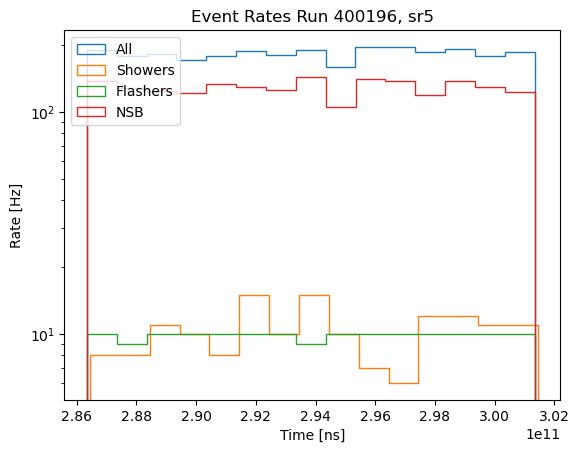

In [3]:
#NEW EVENT RATE SUMMARY FUNCTION (working)

def event_rate_summary(run_id, sr_number , test=False, resolution=1):

    sr_id=sr_number
    r0_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'_r0.tio'

    tcal_file='/data/wipac/CTA/targetcdata/run400032_pedestal.tcal'

    r1_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'.r1'

    reader=get_reader(r0_file, tcal_file, r1_file)

    sr_data= collect_stats(reader)

    cuts=get_cuts()
    
    get_hists(sr_data, cuts, display=test, regions= test, flashers= test, boxes= test)

    sorted_data=sort_data(sr_data, cuts, list=test)

    event_rate(sorted_data, sr_data, run_id, sr_number, test=test, mod=resolution)

event_rate_summary(400196,5)




In [ ]:
# #WORKING/DEBUG CELL READER FUNCTION

# # tcal_ped_path = '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal' # Path to calibrated pedestal file (to be created in this example)

# # r0_file_path = '/data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio' # Path to signal data
# # file_path = '/data/user/fbivens5020/mock_data/run400196_subrun2.r1' # Path to calibrated signal data (to be created in this example)

# # os.system(f"apply_calibration_SCT -p {tcal_ped_path} -i {r0_file_path} -o {file_path}") # This will calibrate the data and make a r1 file. In this I am not using a transfer function so the values here will be in ADC counts. -p in this takes in a pedestal file (.tcal calibrated)

# #READER DEBUG CELL CONTINUED
# reader_r0 = target_io.WaveformArrayReader(r0_file_path) # This loads the signal r0 file
# reader = target_io.WaveformArrayReader(file_path) # This loads the cal r1 file you generated in the previous step

# avwfms = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
# swfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
# ev=0
# for event in range (reader.fNEvents):
#     ev=1+ev

#     wfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
    

#     reader.GetR1Event(event, wfs)

#     swfs = swfs + wfs

# for swf in swfs:
#     plt.plot(swf)
# plt.title(f"r1 data at event 1-{reader.fNEvents}, for all channels, summed")
# plt.xlabel("Sample index")
# plt.ylabel("Amp [ADC counts]") # if without tf function

# plt.show()

# print(np.shape(wfs))

# avwfs = swfs/reader.fNEvents

# for avwf in avwfs:
#     plt.plot(avwf)
# plt.title(f"r1 data at event 1-12245, for all channels, average")
# plt.xlabel("Sample index")
# plt.ylabel("Amp [ADC counts]") # if without tf function

# plt.show()

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun2.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 5864
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

Cannot read the 10th packet of the 4214th event (FITSIO: tried to move past end of file)

65280

test successful
test successful
[WaveformArrayReader] Path: /data/user/fbivens5020/mock_data/run400196_subrun2.r1
[WaveformArrayReader] CameraVersion: 1.1.0
[WaveformArrayReader] IsR1: 0
[WaveformArrayReader] NModules: 25
[WaveformArrayReader] ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
[WaveformArrayReader] NPixels: 1600
[WaveformArrayReader] SkipEvents: 0
[WaveformArrayReader] SkipEndEvents: 0
[WaveformArrayReader] NEvents: 4214
[WaveformArrayReader] NSamples: 64
EventFile::Close()
EventFile::Close()


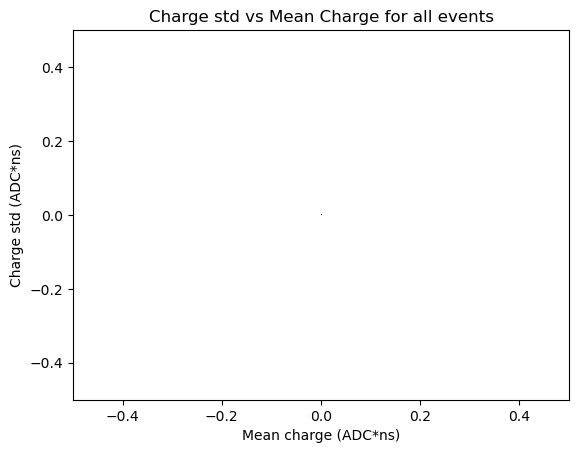

inf


In [ ]:
#EVENT RATES WORKING CELL

#cell that uses all functions then turn that into a function

# reader=get_reader('/data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio', '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal', '/data/user/fbivens5020/mock_data/run400196_subrun2.r1')

# sr_data = collect_stats(reader)

# fig=plt.figure()
# ax=fig.add_subplot(111)
# ax.hist2d(np.isfinite(sr_data[3]), np.isfinite(sr_data[4]), bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))
# plt.title("Charge std vs Mean Charge for all events")
# plt.xlabel("Mean charge (ADC*ns)")
# plt.ylabel("Charge std (ADC*ns)")
# plt.show()

# print(sr_data[3][3])

# cuts=get_cuts()

# get_hists(sr_data, cuts, display=False ,regions=False, flashers=False, boxes=False)




# sorted_data=sort_data(sr_data, cuts)

# print(type(sorted_data))
# for ind in range(9):
#     print(ind,':',type(sorted_data[ind]))
#     print(ind,'shape:',np.shape(sorted_data[ind]))

# event_rate(sorted_data, sr_data, test=True)



In [4]:
#OTHER METRICS FUNCTION

def physical_summary(run_id, sr_number, modules=22):
    run=run_id
    subruns=sr_number+1
    
    fpmTemp_list=[]
    feeTemp_list=[]
    hv_list=[]
    current_list=[]

    for sr in range(subruns):

      fpmTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FPMs_run{run}_subrun{sr}.npy')
      fpmTemp_list.append(fpmTemp_data)

      feeTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FEEs_run{run}_subrun{sr}.npy')
      feeTemp_list.append(feeTemp_data)

      hv_data=np.load(f'/data/user/fbivens5020/mock_data/HV_FPMs_run{run}_subrun{sr}.npy')
      hv_list.append(hv_data)

      current_data=np.load(f'/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{sr}.npy')
      current_list.append(current_data)

    fpmTemps=np.zeros((modules*4,3,len(fpmTemp_list[:])))
    feeTemps=np.zeros((modules*2,3,len(feeTemp_list[:])))
    hv=np.zeros((modules,3,len(hv_list[:])))
    current=np.zeros((modules,3,len(current_list[:])))

    for sr in range(subruns):

        for quad in range(modules*4):
           fpmTemps[quad][0][sr]=sr
           fpmTemps[quad][1][sr]=fpmTemp_list[sr][quad]
           fpmTemps[quad][2][sr]=quad//4

        for board in range(modules*2):
           feeTemps[board][0][sr]=sr
           feeTemps[board][1][sr]=feeTemp_list[sr][board]
           feeTemps[board][2][sr]=board//2

        for mod in range(modules):
           hv[mod][0][sr]=sr
           hv[mod][1][sr]=hv_list[sr][mod]
           hv[mod][2][sr]=mod
           current[mod][0][sr]=sr
           current[mod][1][sr]=current_list[sr][mod]
           current[mod][2][sr]=mod

    fig, (ax1,ax2,ax3,ax4)=plt.subplots(4,1)

    for quad in range(modules*4):
       ax1.plot(fpmTemps[quad][0], fpmTemps[quad][1])
    ax1.set_ylabel("FPM Temp (C)")

    for board in range(modules*2):
       ax2.plot(feeTemps[board][0], feeTemps[board][1])
    ax2.set_ylabel("FEE Temp (C)")

    for mod in range(modules):
       ax3.plot(hv[mod][0],hv[mod][1])
       ax4.plot(current[mod][0],current[mod][1])
    ax3.set_ylabel("HV (V(?))")
    ax4.set_ylabel("Current (A(?))")
    ax4.set_xlabel("Subrun ID")
    fig.tight_layout()
    ax1.set_title(f"Run {run_id} sr 0-{sr_number} physical metrics")
    plt.show()
    


EventFile::Close()
EventFile::Close()


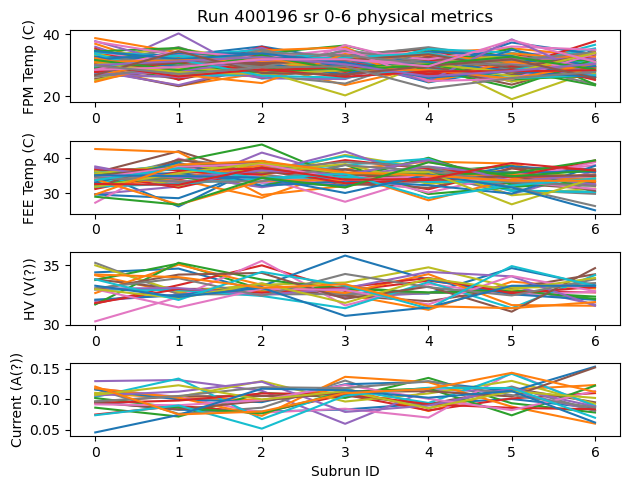

In [9]:
#OTHER METRICS FUNCTION TEST
physical_summary(400196,6)

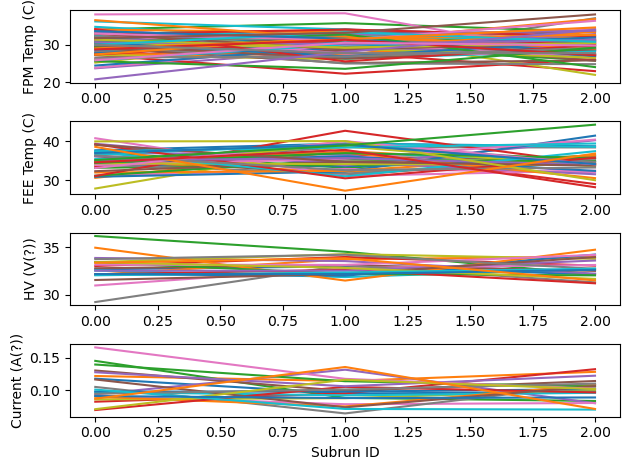

In [8]:
#OTHER METRICS WORKING CELL

run=400196
subruns=3 #line that will eventually change with some stuff
modules=22

fpmTemp_list=[]
feeTemp_list=[]
hv_list=[]
current_list=[]

for sr in range(subruns):

   fpmTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FPMs_run{run}_subrun{sr}.npy')
   fpmTemp_list.append(fpmTemp_data)

   feeTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FEEs_run{run}_subrun{sr}.npy')
   feeTemp_list.append(feeTemp_data)

   hv_data=np.load(f'/data/user/fbivens5020/mock_data/HV_FPMs_run{run}_subrun{sr}.npy')
   hv_list.append(hv_data)

   current_data=np.load(f'/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{sr}.npy')
   current_list.append(current_data)

fpmTemps=np.zeros((modules*4,3,len(fpmTemp_list[:])))
feeTemps=np.zeros((modules*2,3,len(feeTemp_list[:])))
hv=np.zeros((modules,3,len(hv_list[:])))
current=np.zeros((modules,3,len(current_list[:])))

for sr in range(subruns):

   for quad in range(modules*4):
      fpmTemps[quad][0][sr]=sr
      fpmTemps[quad][1][sr]=fpmTemp_list[sr][quad]
      fpmTemps[quad][2][sr]=quad//4

   for board in range(modules*2):
      feeTemps[board][0][sr]=sr
      feeTemps[board][1][sr]=feeTemp_list[sr][board]
      feeTemps[board][2][sr]=board//2

   for mod in range(modules):
      hv[mod][0][sr]=sr
      hv[mod][1][sr]=hv_list[sr][mod]
      hv[mod][2][sr]=mod
      current[mod][0][sr]=sr
      current[mod][1][sr]=current_list[sr][mod]
      current[mod][2][sr]=mod

fig, (ax1,ax2,ax3,ax4)=plt.subplots(4,1)

for quad in range(modules*4):
   ax1.plot(fpmTemps[quad][0], fpmTemps[quad][1])
ax1.set_ylabel("FPM Temp (C)")

for board in range(modules*2):
   ax2.plot(feeTemps[board][0], feeTemps[board][1])
ax2.set_ylabel("FEE Temp (C)")

for mod in range(modules):
   ax3.plot(hv[mod][0],hv[mod][1])
   ax4.plot(current[mod][0],current[mod][1])
ax3.set_ylabel("HV (V(?))")
ax4.set_ylabel("Current (A(?))")
ax4.set_xlabel("Subrun ID")
fig.tight_layout()
plt.show()




[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun6_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun6.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun6_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 3269
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

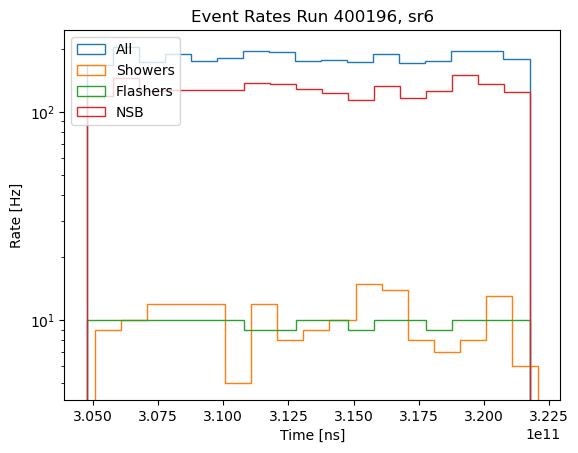

EventFile::Close()
EventFile::Close()


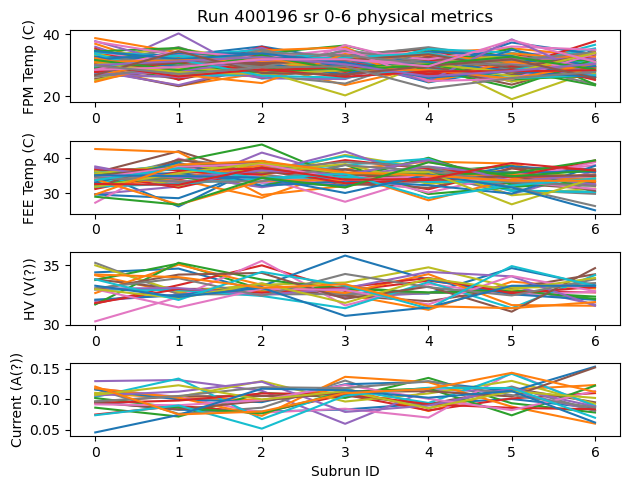

Run 400196 sr6 summary


In [5]:
#CONDENSED FUNCTION CELL

def sr_summary(run_id, sr_number, test=False, resolution=1, modules=22):

    event_rate_summary(run_id, sr_number, test=test, resolution=resolution)

    physical_summary(run_id, sr_number, modules=modules)

    print(f"Run {run_id} sr{sr_number} summary")

sr_summary(400196, 6)
    

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun0_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun0.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun0_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 9261
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

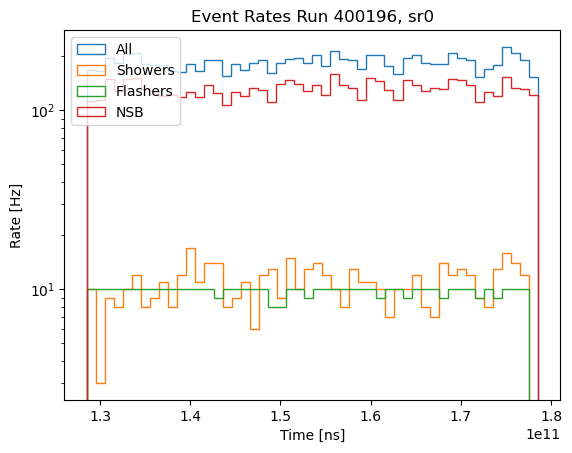

EventFile::Close()
EventFile::Close()


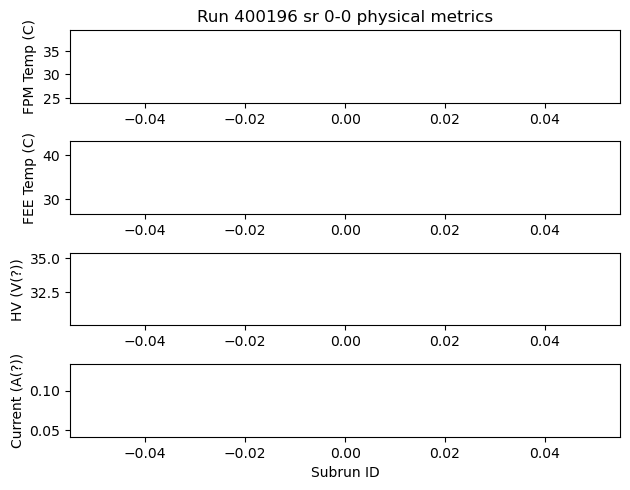

Run 400196 sr0 summary
[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun1_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun1.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun1_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 9062
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrato

: 

In [ ]:
#CONDENSED FUNCTION TESTING (Possibly broken?)



#imagine some function finds the newest run file and spits out
newest_sr=2
run=400196
for sr in range(newest_sr):
    sr_summary(run, sr)
print("done")

In [6]:
#NEWEST FILE DETECTOR function

def get_new_sr(run_base=400195, subrun_base=0):

   run=None
   while run==None:
      if os.path.exists(f"/data/user/fbivens5020/mock_data/Current_FEEs_run{run_base+1}_subrun0.npy")==True:
         run_base=run_base+1
      else:
         run=run_base

   subrun=None
   while subrun==None:
      if os.path.exists(f"/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{subrun_base+1}.npy")==True:
         subrun_base=subrun_base+1
      else:
         subrun=subrun_base
   return run, subrun

get_new_sr()

(400196, 15)

Latest Subrun: Run 400196 sr15
[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun15_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun15.r1
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun15_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 3318
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TMPIX in Ped File: 64
Mon Jun 

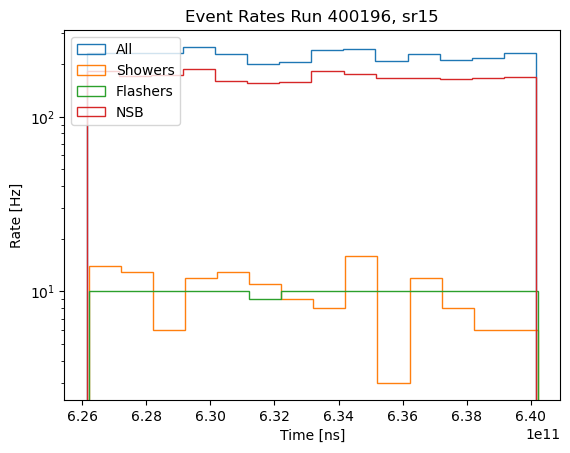

EventFile::Close()
EventFile::Close()
EventFile::Close()
EventFile::Close()


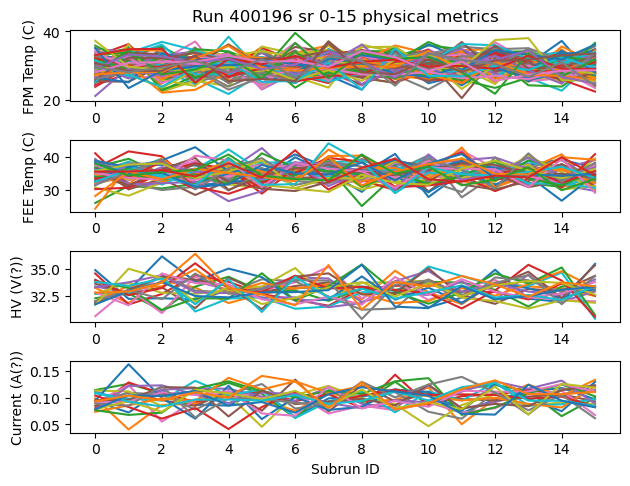

Run 400196 sr15 summary


KeyboardInterrupt: 

In [ ]:
#final loop that actually runs the stuff
#works fine but shouldn't stop till its spit out 30 graphs and I haven't tested the stopping function
active=True

while active==True:
   current_sr=get_new_sr()
   print(f"Latest Subrun: Run {current_sr[0]} sr{current_sr[1]}")
   sr_summary(current_sr[0],current_sr[1])
   next_sr=get_new_sr()
   while current_sr==next_sr:
      next_sr=get_new_sr()
      if current_sr[1]==15:
         active=False
         break

In [7]:
#Working cell for overall event rate graph. 
run_id=400196

sr_id=3

r0_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'_r0.tio'

tcal_file='/data/wipac/CTA/targetcdata/run400032_pedestal.tcal'

r1_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'.r1'

reader=get_reader(r0_file, tcal_file, r1_file)

workingsr_data=collect_stats(reader)

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun3_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun3.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun3_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 537
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numbe